In [1]:
from data import COMPASSGraphDataset
from utils import plot_graph
from torch_geometric.loader import DataLoader
from torch import serialization
import torch
import numpy as np
from data import TemporalData  # 从你的data模块导入TemporalData类
serialization.add_safe_globals([TemporalData])  # 加入安全白名单,就不会报加载的警告了

In [2]:
def randomChooseTimeAndSlice(data: TemporalData):
    """
    从时间序列数据中随机选择一个20s内的未来时间点，然后将选择的未来特征切片赋值给y,并设置timestamp为未来时间点
    """
    timestamp = torch.randint(1,20,(1,)).long()
    nodes_number = data.x.shape[0]
    y_nodes_idx = torch.arange(0, nodes_number) + nodes_number*(timestamp - 1)
    data.y = data.y[y_nodes_idx,:] # 取未来时刻标签
    data.timestamp = timestamp.clone().detach().float()  # 若timestamp是张量时用这个
    return data

In [3]:
dataset = COMPASSGraphDataset(root="../../../data/dataset/CompassGraphDataset", transform=randomChooseTimeAndSlice)
print(f"✅ 数据集加载完成，有效样本数：{len(dataset)}")
loader = DataLoader(dataset, batch_size=6,shuffle=True)

max_node_number = 0
# 枚举数据集
for step, batch in enumerate(loader):
    # batch = batch.to('cuda')
    print(batch)
    # print(f"Step {step + 1}:")
    # print('=============')
    # print(f'Number of graphs in the current batch:{batch.num_graphs}')
    # print(batch)
    # print('batch.timestamp:', batch.timestamp)
    # print('batch.action_acc:', batch.action_acc)
    # print('batch.action_lc:', batch.action_lc)
    # print('batch.batch:', batch.batch)
    # print('batch.ptr:', batch.ptr)
    
    
    # 从batch中提取单个图进行可视化测试
    single_graph = batch.to_data_list()[0]  # 提取第一个图
    # plot_graph(single_graph, feature='risk')  # 可视化该图，颜色映射到risk_field特征
    # 打印图的基本信息
    print(f"edge_index维度：{single_graph.edge_index.shape}")  # 预期 (2, 11645)
    print(f"节点特征维度：{single_graph.x.shape}")            # 预期 (4301, 特征数)
    print(f"边特征维度：{single_graph.edge_attr.shape}")      # 预期 (11645, 特征数)
    print(f"PyG有向图节点数：{single_graph.num_nodes}")  # 4301（由x的行数自动推断）
    print(f"PyG有向图边数：{single_graph.num_edges}")    # 11645
    print(f"是否为有向图：{single_graph.is_directed()}") # True
    break

✅ 数据集加载完成，有效样本数：7126
TemporalDataBatch(x=[21644, 533], edge_index=[2, 118478], edge_attr=[118478, 5], y=[21644, 25], action_acc=[6, 41], action_lc=[6, 41], timestamp=[6], batch=[21644], ptr=[7])
edge_index维度：torch.Size([2, 19916])
节点特征维度：torch.Size([3594, 533])
边特征维度：torch.Size([19916, 5])
PyG有向图节点数：3594
PyG有向图边数：19916
是否为有向图：True


In [9]:
max_node_number

6328

In [5]:
from torch_geometric.data import TemporalData

from torch_geometric.nn import GCNConv, TransformerConv, GATv2Conv
import torch
import torch.nn as nn
import torch.nn.functional as F



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)
batch = batch.to(device)
class TestModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gatv2_conv = GATv2Conv(531, 128, edge_dim=5, heads=4, concat=True)
        self.linear1 = nn.Linear(512, 128)
        self.trans_conv = TransformerConv(128, 128, edge_dim=5, heads=4, concat=True)
        self.linear2 = nn.Linear(512, 128)
        self.GELU = nn.GELU()
        self.linear3 = nn.Linear(128, 1)
        
    def forward(self, batch):
        batch_x = self.gatv2_conv(batch.x[:,2:], batch.edge_index, batch.edge_attr)
        batch_x = self.linear1(batch_x)
        batch_x = self.trans_conv(batch_x, batch.edge_index, batch.edge_attr)
        batch_x = self.GELU(self.linear2(batch_x))
        batch_x = torch.sigmoid(self.linear3(batch_x))
        return batch_x

# model = torch.compile(TestModel(),dynamic=True,backend="aot_eager").to(device)
model = TestModel().to(device)

import time
tic = time.time()
batch_x = model(batch)
toc = time.time()
print(toc-tic)
print(batch_x.shape)


cuda
0.95578932762146
torch.Size([7719, 1])


In [5]:
criterion = torch.nn.MSELoss()
batch.y[:,5]
loss = criterion(batch.y[:,5].unsqueeze(1),batch_x)
print(loss)

tensor(0.1681, device='cuda:0', grad_fn=<MseLossBackward0>)


TemporalData(x=[5084, 3], edge_index=[2, 26918], edge_attr=[26918, 5], y=[5084, 25], action_acc=[1, 41], action_lc=[1, 41], timestamp=[1])


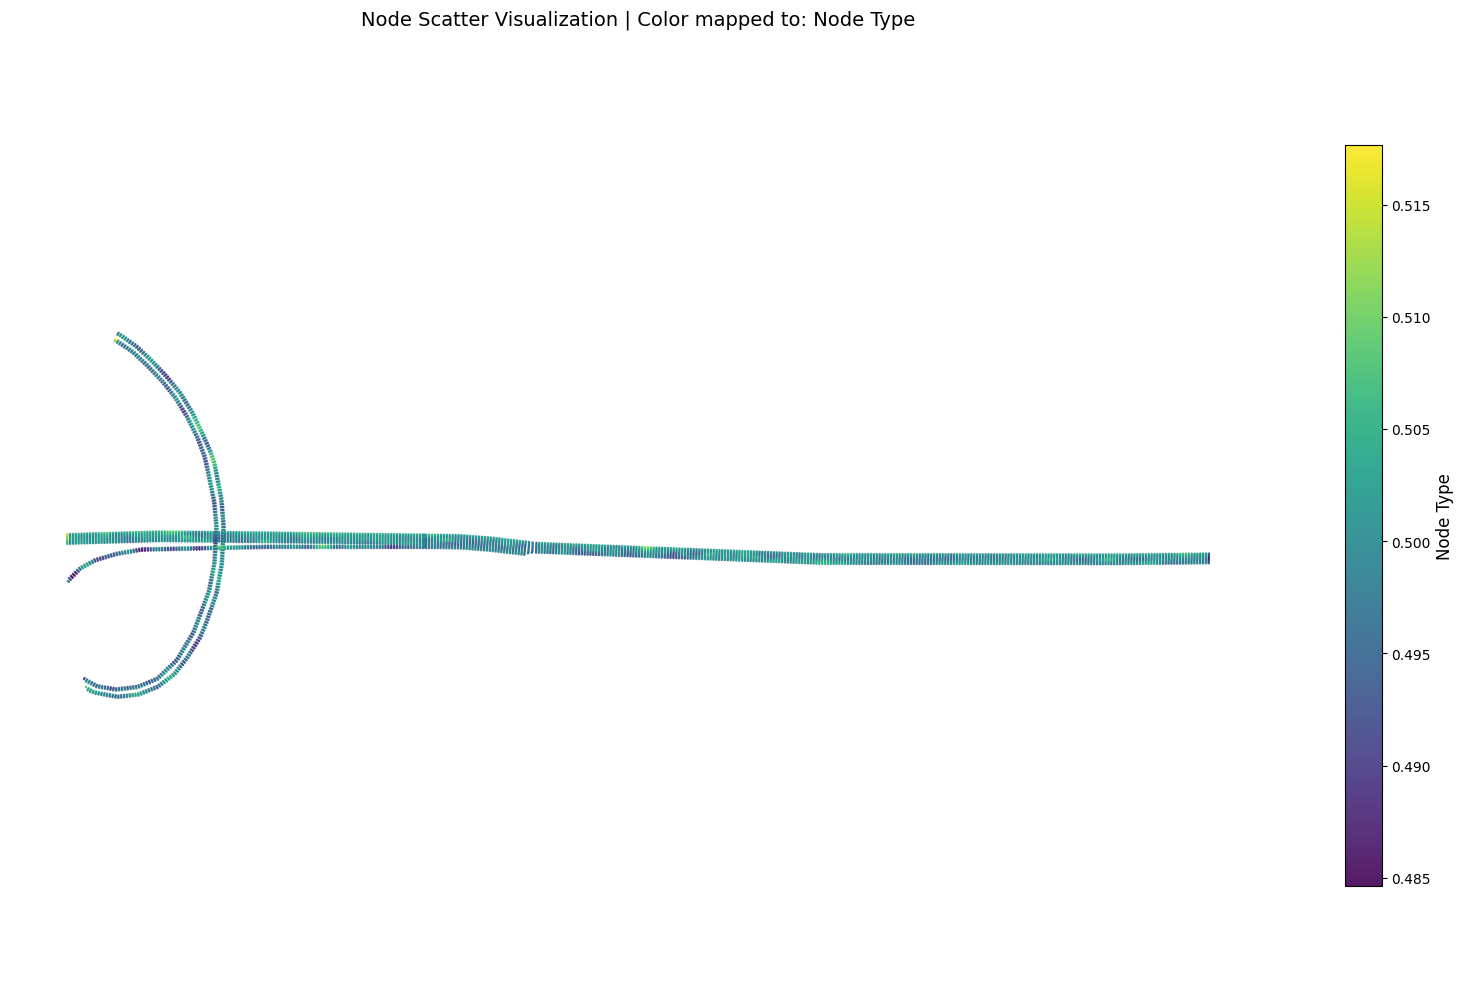

In [6]:
new_batch_graph = batch.clone().detach()
new_batch_graph.x = torch.cat([batch.x[:,:2],batch_x], dim=1)
d = new_batch_graph.to_data_list()

print(d[0])
plot_graph(d[0],feature='node_type')


In [7]:

# 计算节点间相对距离矩阵
pos = batch[0].x[:, :2]  # [n, 2], (x, y)
tic = time.time()
for _ in range(100):
    rel_pos = pos.unsqueeze(1) - pos.unsqueeze(0)  # [n, n, 2]
    dist = torch.norm(rel_pos, dim=-1)  # [n, n], 欧氏距离
toc = time.time()
print(f"计算距离矩阵耗时: {toc - tic:.6f} 秒")

print(dist.shape)


计算距离矩阵耗时: 0.025614 秒
torch.Size([5084, 5084])


In [2]:
import torch
torch.cuda.empty_cache()

In [14]:
batch

TemporalDataBatch(x=[118680, 533], edge_index=[2, 646210], edge_attr=[646210, 5], y=[118680, 25], action_acc=[32, 41], action_lc=[32, 41], timestamp=[32], batch=[118680], ptr=[33])

In [15]:
torch.sum(batch.y[:,4])/batch.y.shape[0]

tensor(0.0062)

In [10]:
max_y = torch.max(batch.y,dim=0).values.cpu().detach()
for _ in max_y:
    print(_)
print(max_y.shape)


tensor(1.)
tensor(0.8013)
tensor(2.1823)
tensor(0.1067)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
torch.Size([25])


In [11]:
x = torch.randint(0,10, [10,3]) * torch.FloatTensor([1,20,2]) - torch.FloatTensor([3,50,5])
print(x)

tensor([[  5.,  50.,   7.],
        [ -2.,  30.,   5.],
        [  1.,  30.,   3.],
        [  1., -10.,   7.],
        [  0., -50.,  11.],
        [ -3.,  10.,   9.],
        [ -2.,  50.,  11.],
        [  6.,  10.,  11.],
        [  3., 130.,   7.],
        [  0., 110.,  -1.]])


In [12]:
LN = torch.nn.LayerNorm(x.shape[1:])
BN = torch.nn.BatchNorm1d(x.shape[1])
print(LN(x))
print(BN(x))


tensor([[-0.7547,  1.4131, -0.6584],
        [-0.9464,  1.3833, -0.4368],
        [-0.7814,  1.4115, -0.6301],
        [ 0.2368, -1.3258,  1.0891],
        [ 0.4897, -1.3938,  0.9041],
        [-1.4108,  0.7901,  0.6208],
        [-0.9806,  1.3728, -0.3922],
        [-1.3887,  0.4629,  0.9258],
        [-0.7408,  1.4137, -0.6729],
        [-0.6975,  1.4142, -0.7167]], grad_fn=<NativeLayerNormBackward0>)
tensor([[ 1.4415,  0.2765,  0.0000],
        [-1.0196, -0.1185, -0.5423],
        [ 0.0352, -0.1185, -1.0847],
        [ 0.0352, -0.9084,  0.0000],
        [-0.3164, -1.6984,  1.0847],
        [-1.3712, -0.5135,  0.5423],
        [-1.0196,  0.2765,  1.0847],
        [ 1.7931, -0.5135,  1.0847],
        [ 0.7383,  1.8564,  0.0000],
        [-0.3164,  1.4614, -2.1693]], grad_fn=<NativeBatchNormBackward0>)


In [13]:
torch.min(torch.sigmoid(x),dim=0).values

tensor([4.7426e-02, 1.9287e-22, 2.6894e-01])

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, TransformerConv
import math

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        # t: (B,) floats (works for continuous t too)
        device = t.device
        half = self.dim // 2
        emb = torch.exp(torch.arange(half, device=device) * -(math.log(10000) / (half - 1)))
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb  # (B, dim)

In [15]:
base_ch = 128
time_emb_dim = 512

time_mlp = nn.Sequential(
            SinusoidalPosEmb(base_ch),
            nn.Linear(base_ch, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )


In [26]:
batch_size = 2
x = torch.randn(batch_size)
time_emb = time_mlp(x).to(batch.x.device)
print(time_emb.shape)


torch.Size([2, 512])


In [27]:
batch.batch

tensor([0, 0, 0,  ..., 1, 1, 1], device='cuda:0')

In [28]:
batch.x.shape

torch.Size([8954, 533])

In [30]:
expanded_time_emb = time_emb[batch.batch]  # [N, 512]

print(expanded_time_emb.shape)


torch.Size([8954, 512])


In [18]:
batch

TemporalDataBatch(x=[21644, 533], edge_index=[2, 118478], edge_attr=[118478, 5], y=[21644, 25], action_acc=[6, 41], action_lc=[6, 41], timestamp=[6], batch=[21644], ptr=[7])

In [ ]:
from torch_geometric.nn import Polynormer,SGFormer,SGFormerAttention
from torch_geometric.nn import GATv2Conv
from model import EnhancedPolynormer
torch.cuda.empty_cache()
device = 'cuda' if torch.cuda.is_available() else 'cpu'

channel_in = 531

# def reshape_batch(batch, padding=0):
#     B = batch.ptr.shape[0] - 1
#     N_max = 7000
    
#     return x_reshape 

batch = batch.to(device)
# attn = EnhancedPolynormer(in_channels=channel_in, hidden_channels=64, out_channels = 2, 
#                               local_layers = 7, global_layers = 2, heads=4, local_attn=True, edge_dim=5).to(device)
# x_p = polyattn(batch.x[:,2:], batch.edge_index, batch.batch, batch.edge_attr)
attn = SGFormer(in_channels=channel_in, hidden_channels=64, out_channels = 2, 
                              trans_num_layers=2,trans_num_heads=4,gnn_num_layers=3).to(device)
x_p = attn(batch.x[:,2:], batch.edge_index, batch.batch)

# attn = Polynormer(in_channels=channel_in, hidden_channels=64, out_channels = 2, 
#                               local_layers = 7, global_layers = 2, heads=4, local_attn=True).to(device)

# x_p = polyattn(batch.x[:,2:], batch.edge_index, batch.batch)

print(x_p)
print(x_p.shape)
# del x_p
# torch.cuda.empty_cache()


tensor([[-0.8496, -0.5579],
        [-0.3447, -1.2325],
        [-1.0563, -0.4273],
        ...,
        [-1.0111, -0.4523],
        [-0.6654, -0.7217],
        [-0.4533, -1.0093]], device='cuda:0', grad_fn=<LogSoftmaxBackward0>)
torch.Size([21644, 2])


In [ ]:
del x_p, attn
torch.cuda.empty_cache()

In [6]:
import torch

x = torch.max(torch.randint(1,2,(100,)))
print(x)

tensor(1)
